In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
from backend.datasets.unified_dataset import UnifiedDataset

dataset = UnifiedDataset(
    mri_path="../data/figshare",
    esad_path="../data/ESAD",
    mesad_path="../data/mesad"
)

In [6]:
from backend.datasets.mri_loader import load_sample as load_mri_sample

In [7]:
import random
import numpy as np

heights = []
widths = []

for file in dataset.mri_files[:500]:  # sample first 500

    sample = load_mri_sample(file)

    h, w = sample["image"].shape[:2]

    heights.append(h)
    widths.append(w)

print("MRI")
print("Min:", min(heights), "x", min(widths))
print("Max:", max(heights), "x", max(widths))
print("Mean:", round(np.mean(heights)), "x", round(np.mean(widths)))

MRI
Min: 512 x 512
Max: 512 x 512
Mean: 512 x 512


In [8]:
heights = []
widths = []

for i in range(500):

    sample = dataset.esad_loader.load_sample(i)

    h, w = sample["image"].shape[:2]

    heights.append(h)
    widths.append(w)

print("ESAD")
print("Min:", min(heights), "x", min(widths))
print("Max:", max(heights), "x", max(widths))
print("Mean:", round(np.mean(heights)), "x", round(np.mean(widths)))

ESAD
Min: 1080 x 1920
Max: 1080 x 1920
Mean: 1080 x 1920


In [9]:
heights = []
widths = []

for i in range(500):

    sample = dataset.mesad_loader.load_sample(i)

    h, w = sample["image"].shape[:2]

    heights.append(h)
    widths.append(w)

print("MESAD")
print("Min:", min(heights), "x", min(widths))
print("Max:", max(heights), "x", max(widths))
print("Mean:", round(np.mean(heights)), "x", round(np.mean(widths)))

MESAD
Min: 576 x 720
Max: 576 x 720
Mean: 576 x 720


In [10]:
widths = []
heights = []

for i in range(1000):

    sample = dataset.esad_loader.load_sample(i)

    for xmin, ymin, xmax, ymax in sample["boxes"]:

        widths.append(xmax - xmin)
        heights.append(ymax - ymin)

print("ESAD BBoxes")
print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Mean Width:", np.mean(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Mean Height:", np.mean(heights))

ESAD BBoxes
Min Width: 194
Max Width: 888
Mean Width: 354.16056034482756
Min Height: 158
Max Height: 744
Mean Height: 307.3663793103448


In [11]:
widths = []
heights = []

for i in range(1000):

    sample = dataset.mesad_loader.load_sample(i)

    for xmin, ymin, xmax, ymax in sample["boxes"]:

        widths.append(xmax - xmin)
        heights.append(ymax - ymin)

print("MESAD BBoxes")
print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Mean Width:", np.mean(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Mean Height:", np.mean(heights))

MESAD BBoxes
Min Width: 84
Max Width: 506
Mean Width: 212.40235910878113
Min Height: 57
Max Height: 506
Mean Height: 192.23656618610747


In [12]:
from backend.preprocessing.bbox_utils import scale_bbox

bbox = [100, 100, 200, 200]

scaled = scale_bbox(
    bbox,
    original_width=1000,
    original_height=1000,
    target_width=500,
    target_height=500
)

print(scaled)

[50, 50, 100, 100]


In [15]:
sample = dataset.esad_loader.load_sample(0)

print(sample["image"].shape)
print(len(sample['boxes']))
print(sample["boxes"])

(1080, 1920, 3)
0
[]


In [16]:
for i in range(len(dataset.esad_loader)):

    sample = dataset.esad_loader.load_sample(i)

    if len(sample["boxes"]) > 0:

        print("Found:", i)
        print("Boxes:", len(sample["boxes"]))
        break

Found: 3
Boxes: 2


In [17]:
sample = dataset.esad_loader.load_sample(3)

print(sample["image"].shape)
print(sample["boxes"])

(1080, 1920, 3)
[[448, 240, 943, 544], [1009, 221, 1327, 524]]


In [18]:
from backend.preprocessing.image_transforms import resize_sample

resized = resize_sample(sample)

print(sample["image"].shape)
print(resized["image"].shape)

print(sample["boxes"])
print(resized["boxes"])

(1080, 1920, 3)
(512, 512, 3)
[[448, 240, 943, 544], [1009, 221, 1327, 524]]
[[119, 113, 251, 257], [269, 104, 353, 248]]


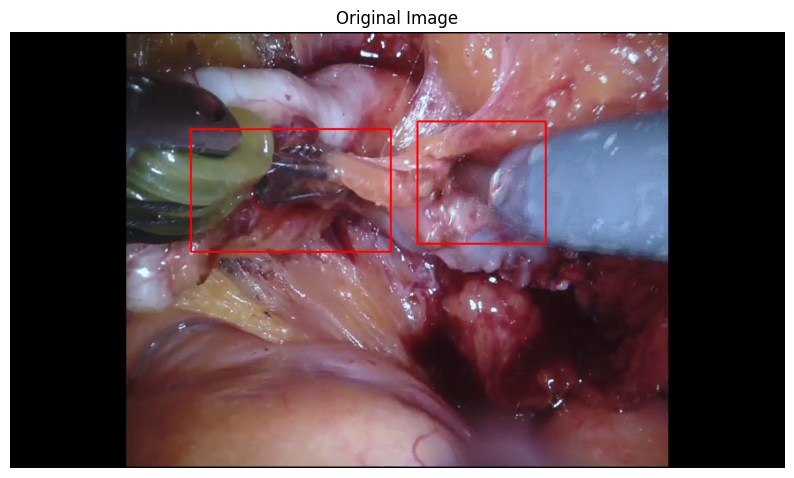

In [19]:
import cv2
import matplotlib.pyplot as plt

sample = dataset.esad_loader.load_sample(3)

image = sample["image"].copy()

for box in sample["boxes"]:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

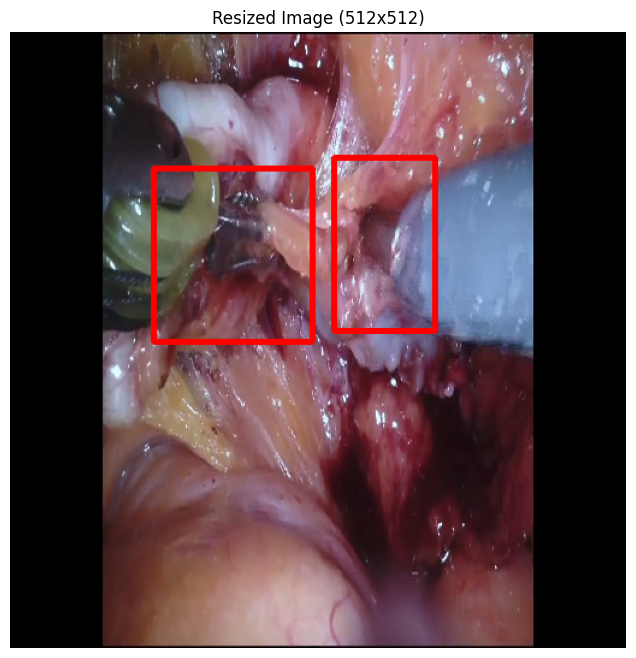

In [20]:
from backend.preprocessing.image_transforms import resize_sample

resized = resize_sample(sample)

image = resized["image"].copy()

for box in resized["boxes"]:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("Resized Image (512x512)")
plt.axis("off")
plt.show()

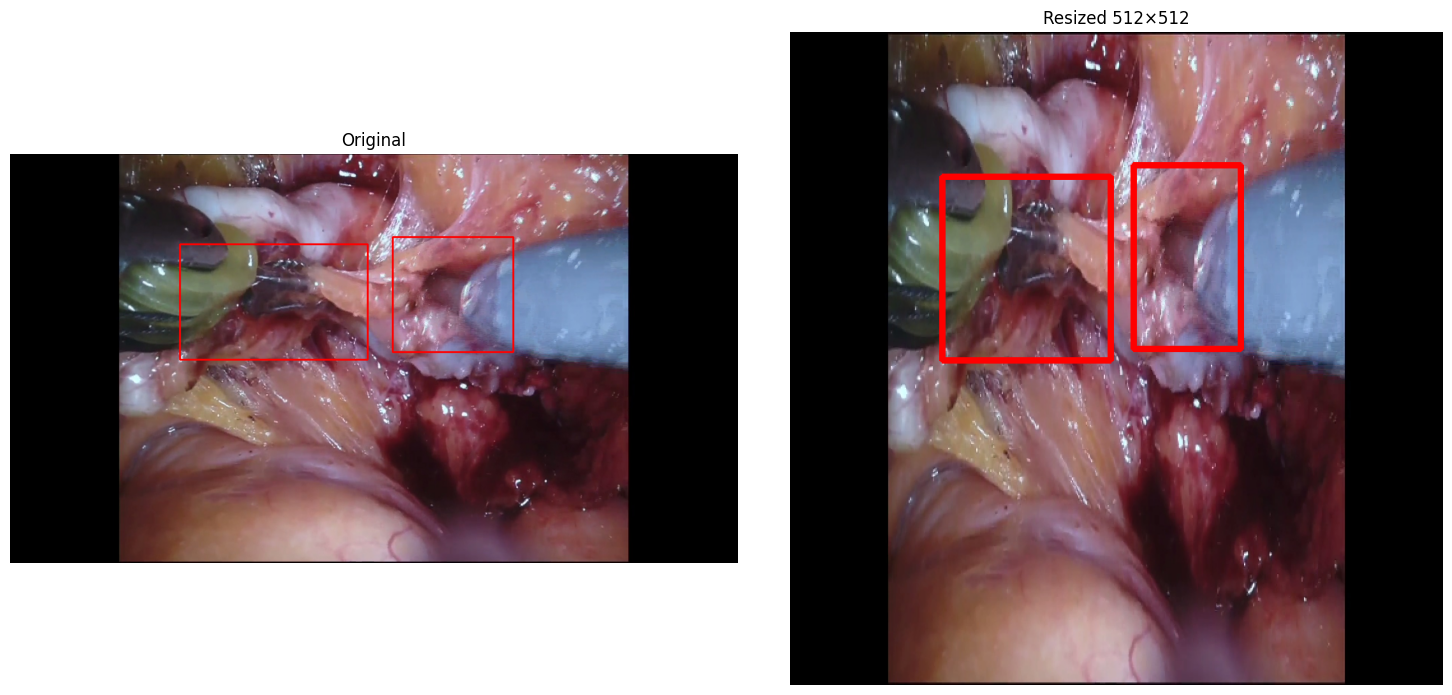

In [21]:
from backend.preprocessing.image_transforms import resize_sample
import cv2
import matplotlib.pyplot as plt

sample = dataset.esad_loader.load_sample(3)

# Original
original = sample["image"].copy()

for box in sample["boxes"]:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(
        original,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        3
    )

# Resized
resized = resize_sample(sample)

resized_img = resized["image"].copy()

for box in resized["boxes"]:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(
        resized_img,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        3
    )

# Display
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title("Resized 512×512")
plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
from backend.preprocessing.normalizer import normalize_image

sample = dataset.esad_loader.load_sample(3)

image = sample["image"]

normalized = normalize_image(image)

print("Original dtype:", image.dtype)

print("Normalized dtype:", normalized.dtype)

print("Min:", normalized.min())
print("Max:", normalized.max())

Original dtype: uint8
Normalized dtype: float32
Min: 0.0
Max: 1.0


In [31]:
import importlib

import backend.preprocessing.normalizer

importlib.reload(
    backend.preprocessing.normalizer
)

<module 'backend.preprocessing.normalizer' from 'e:\\sandyyyy\\Mini project\\MedSearch-RL\\backend\\preprocessing\\normalizer.py'>

In [33]:
from backend.preprocessing.normalizer import normalize_sample

normalized_sample = normalize_sample(sample)

print(
    normalized_sample["image"].dtype
)

print(
    normalized_sample["image"].min()
)

print(
    normalized_sample["image"].max()
)

float32
0.0
1.0


In [35]:
from backend.preprocessing.pipeline import preprocess_sample
sample = dataset.esad_loader.load_sample(3)

processed = preprocess_sample(sample)

print(processed["image"].shape)
print(processed["image"].dtype)

print(processed["boxes"])

(512, 512, 3)
float32
[[119, 113, 251, 257], [269, 104, 353, 248]]
